# K-Means Clustering From Scratch

This notebook demonstrates a complete implementation of K-Means clustering.

## Learning objectives

By the end of this notebook, we will understand:

- What K-Means clustering is
- How centroid initialization works
- How Euclidean distance is calculated
- How points are assigned to clusters
- How centroids are updated
- How convergence works
- What inertia means
- How to choose K using the Elbow Method
- How to evaluate clustering using the Silhouette Score
- Why feature scaling matters
- How our implementation compares with scikit-learn

## Algorithm

K-Means repeatedly performs two steps:

1. Assignment step
   - Assign every point to its nearest centroid.

2. Update step
   - Recalculate each centroid as the mean of its assigned points.

This continues until the centroids stop moving significantly or the maximum number of iterations is reached.


### Import packages

In [53]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans as SklearnKMeans

# Allow importing src/kmeans.py when running this notebook
PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

# Only for local
# from src.kmeans import KMeans

# for colab runtime
from kmeans import KMeans


## 2. Create a Dataset

We will create a small 2D dataset containing three naturally separated groups.


In [54]:
X = np.array([
    # Cluster 1
    [1.0, 2.0],
    [1.5, 1.8],
    [1.2, 0.8],
    [2.0, 1.5],
    [1.8, 2.2],

    # Cluster 2
    [7.0, 8.0],
    [8.0, 8.5],
    [8.5, 7.5],
    [7.5, 7.0],
    [9.0, 8.0],

    # Cluster 3
    [4.0, 4.0],
    [4.5, 5.0],
    [5.0, 4.5],
    [5.5, 5.0],
    [4.8, 3.8],
])

print("Dataset shape:", X.shape)
print(X)


Dataset shape: (15, 2)
[[1.  2. ]
 [1.5 1.8]
 [1.2 0.8]
 [2.  1.5]
 [1.8 2.2]
 [7.  8. ]
 [8.  8.5]
 [8.5 7.5]
 [7.5 7. ]
 [9.  8. ]
 [4.  4. ]
 [4.5 5. ]
 [5.  4.5]
 [5.5 5. ]
 [4.8 3.8]]


## 3. Visualize the Dataset


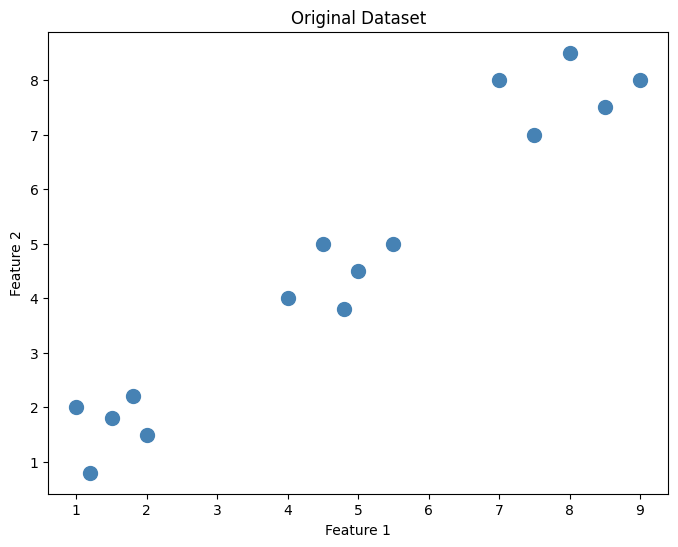

In [55]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X[:, 0],
    X[:, 1],
    s=100,
    color="steelblue"
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Original Dataset")

plt.show()


## 4. Train K-Means From Scratch

We will use:

- K = 3
- Maximum iterations = 100
- Tolerance = 1e-4
- Random seed = 42

The random seed makes the experiment reproducible.


In [56]:
model = KMeans(
    k=3,
    max_iters=100,
    tolerance=1e-4,
    random_state=42
)

labels = model.fit_predict(X)

print("Training complete.")
print("Iterations:", model.n_iter_)
print("Final centroids:")
print(model.centroids)
print("Final inertia:", model.inertia_)
print("Labels:")
print(labels)


Training complete.
Iterations: 2
Final centroids:
[[8.   7.8 ]
 [1.5  1.66]
 [4.76 4.46]]
Final inertia: 8.156
Labels:
[1 1 1 1 1 0 0 0 0 0 2 2 2 2 2]


## 5. Visualize the Final Clusters

Each color represents a cluster.

The red X markers represent the learned centroids.


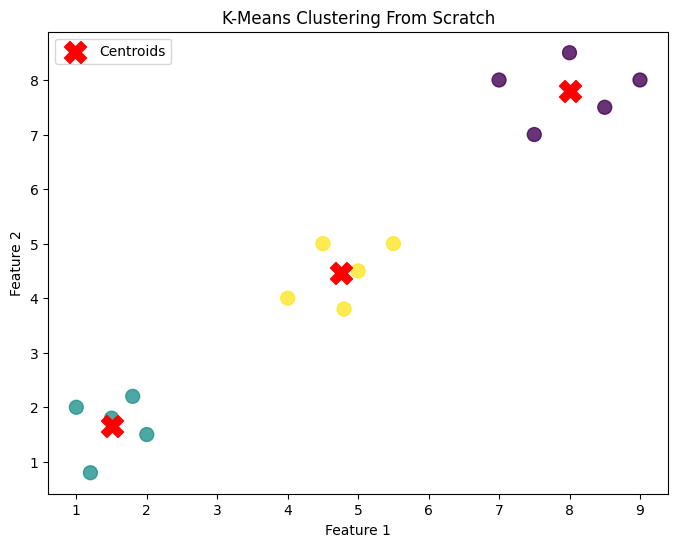

In [57]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X[:, 0],
    X[:, 1],
    c=labels,
    cmap="viridis",
    s=100,
    alpha=0.8
)

plt.scatter(
    model.centroids[:, 0],
    model.centroids[:, 1],
    marker="X",
    color="red",
    s=250,
    label="Centroids"
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("K-Means Clustering From Scratch")
plt.legend()

plt.show()


## 6. Inspect the Cluster Assignments

The numerical cluster labels themselves have no inherent meaning.

For example, cluster `0` and cluster `1` can be swapped without changing the quality of the clustering.

What matters is which points belong together.


In [58]:
for cluster_id in range(model.k):
    cluster_points = X[labels == cluster_id]

    print(f"\nCluster {cluster_id}")
    print(cluster_points)



Cluster 0
[[7.  8. ]
 [8.  8.5]
 [8.5 7.5]
 [7.5 7. ]
 [9.  8. ]]

Cluster 1
[[1.  2. ]
 [1.5 1.8]
 [1.2 0.8]
 [2.  1.5]
 [1.8 2.2]]

Cluster 2
[[4.  4. ]
 [4.5 5. ]
 [5.  4.5]
 [5.5 5. ]
 [4.8 3.8]]


## 7. Visualize Centroid Movement

During training, K-Means repeatedly moves the centroids.

The `centroid_history` attribute stores their positions after every iteration.

This allows us to visualize the optimization process.


In [59]:
history = np.array(model.centroid_history)

print("Number of recorded centroid positions:", len(history))
print("History shape:", history.shape)


Number of recorded centroid positions: 3
History shape: (3, 3, 2)


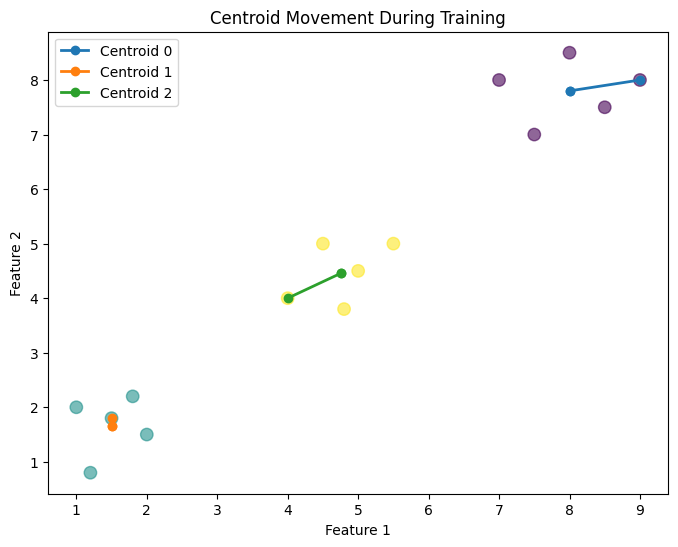

In [60]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X[:, 0],
    X[:, 1],
    c=labels,
    cmap="viridis",
    s=80,
    alpha=0.6
)

for cluster_id in range(model.k):

    plt.plot(
        history[:, cluster_id, 0],
        history[:, cluster_id, 1],
        marker="o",
        linewidth=2,
        label=f"Centroid {cluster_id}"
    )

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Centroid Movement During Training")
plt.legend()

plt.show()


## 8. Inertia

Inertia measures the total squared distance between each data point and its assigned centroid.

The objective of K-Means is to minimize this value.

\[
J = \sum_i ||x_i - c_{label_i}||^2
\]

Lower inertia means the points are closer to their assigned centroids.

However, inertia always tends to decrease when K increases, so it cannot be used alone to select K.


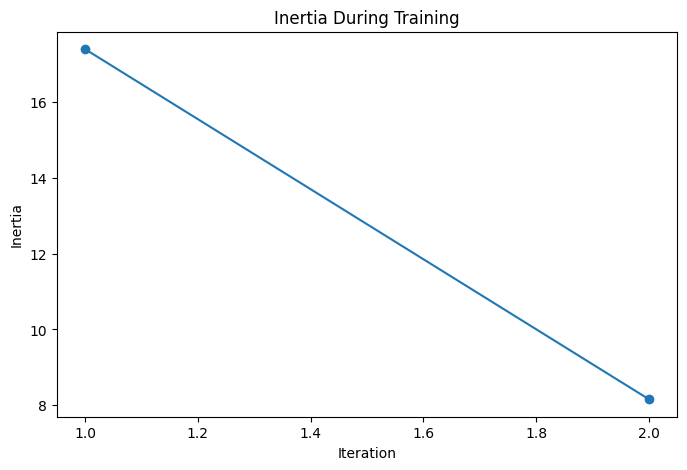

In [61]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(model.inertia_history) + 1),
    model.inertia_history,
    marker="o"
)

plt.xlabel("Iteration")
plt.ylabel("Inertia")
plt.title("Inertia During Training")

plt.show()


## 9. Elbow Method

K-Means requires us to choose K before training.

We can train models using several K values and compare their inertia.

As K increases, inertia decreases.

We look for an "elbow" where adding additional clusters produces diminishing improvement.


In [62]:
k_values = range(1, 11)

inertias = []

for k in k_values:

    model_k = KMeans(
        k=k,
        max_iters=100,
        tolerance=1e-4,
        random_state=42
    )

    model_k.fit(X)

    inertias.append(model_k.inertia_)

print("K values:", list(k_values))
print("Inertias:", inertias)


K values: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Inertias: [np.float64(208.27333333333337), np.float64(62.289), np.float64(8.156), np.float64(6.272666666666666), np.float64(5.231), np.float64(4.606), np.float64(4.1850000000000005), np.float64(2.735), np.float64(2.006666666666667), np.float64(2.6733333333333333)]


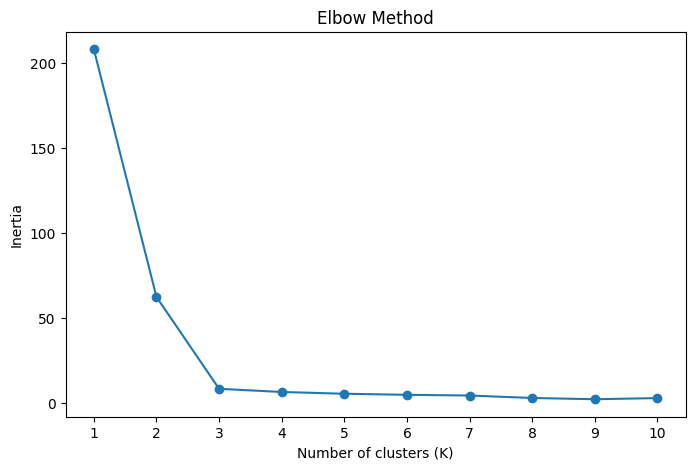

In [63]:
plt.figure(figsize=(8, 5))

plt.plot(
    k_values,
    inertias,
    marker="o"
)

plt.xlabel("Number of clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.xticks(list(k_values))

plt.show()


## 10. Silhouette Score

The Silhouette Score measures how well-separated the clusters are.

It considers:

- How close a point is to other points in its own cluster.
- How far the point is from points in neighboring clusters.

The score is approximately between -1 and +1.

Higher values generally indicate better-defined clusters.


In [64]:
k_values = range(2, 11)

inertias = []
silhouette_scores = []

for k in k_values:

    model_k = KMeans(
        k=k,
        max_iters=100,
        tolerance=1e-4,
        random_state=42
    )

    labels_k = model_k.fit_predict(X)

    inertias.append(model_k.inertia_)

    score = silhouette_score(
        X,
        labels_k
    )

    silhouette_scores.append(score)
    print(score)


0.5897518904513855
0.7436638663911251
0.588890924182846
0.5532401440770779
0.5413137339333055
0.0734698601747689
0.1484531041970002
0.19856024518720478
0.10492707719230637


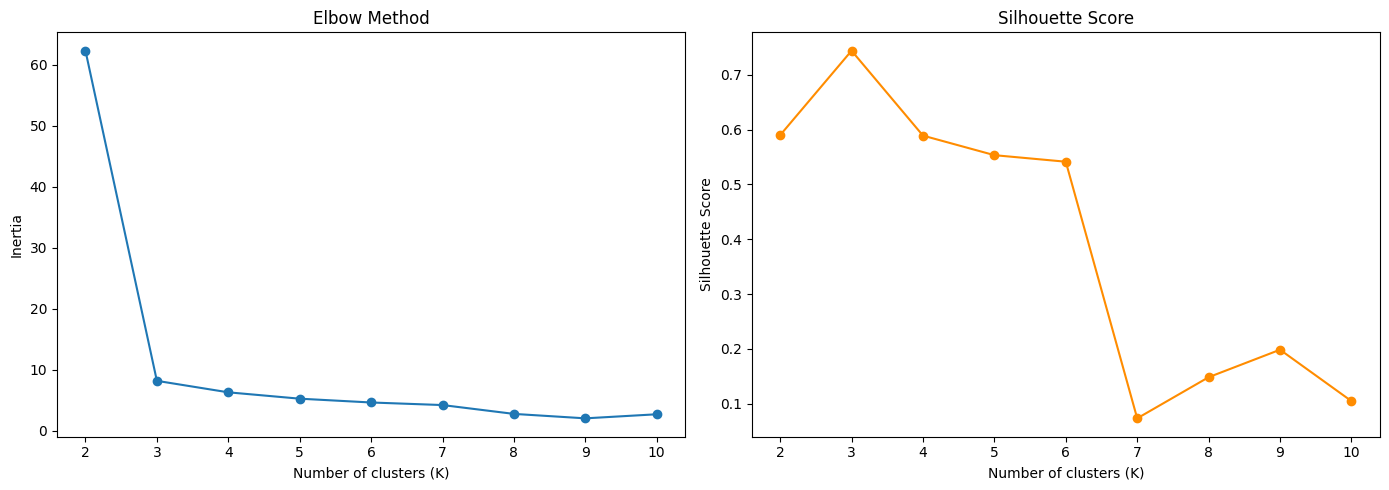

In [65]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5)
)

# Elbow plot
axes[0].plot(
    list(k_values),
    inertias,
    marker="o"
)

axes[0].set_xlabel("Number of clusters (K)")
axes[0].set_ylabel("Inertia")
axes[0].set_title("Elbow Method")

# Silhouette plot
axes[1].plot(
    list(k_values),
    silhouette_scores,
    marker="o",
    color="darkorange"
)

axes[1].set_xlabel("Number of clusters (K)")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Score")

plt.tight_layout()
plt.show()


In [66]:
best_k = list(k_values)[
    np.argmax(silhouette_scores)
]

best_score = max(silhouette_scores)

print("Best K according to silhouette score:", best_k)
print("Best silhouette score:", best_score)


Best K according to silhouette score: 3
Best silhouette score: 0.7436638663911251


## 11. Why Feature Scaling Matters

K-Means uses Euclidean distance.

If one feature has a much larger numerical scale than another, it can dominate the distance calculation.

For example:

- Age: 18–80
- Income: 20,000–200,000

Income would dominate the distance calculation.

Standardization transforms features approximately to:
For our current synthetic dataset the features have similar scales, but scaling becomes very important in real-world datasets.


In [67]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Original first row:")
print(X[0])

print("\nScaled first row:")
print(X_scaled[0])


Original first row:
[1. 2.]

Scaled first row:
[-1.38564913 -1.03171189]


## 12. Predict New Points

After training, we can assign new observations to the nearest learned centroid.


In [68]:
new_points = np.array([
    [1.4, 1.4],
    [8.2, 8.1],
    [5.0, 4.2]
])

predictions = model.predict(new_points)

for point, prediction in zip(new_points, predictions):
    print(
        f"Point {point} → Cluster {prediction}"
    )


Point [1.4 1.4] → Cluster 1
Point [8.2 8.1] → Cluster 0
Point [5.  4.2] → Cluster 2


## 13. Compare With scikit-learn

Our implementation is intentionally simple and educational.

Now we compare it with scikit-learn's implementation.

Important:

The cluster numbers do not have fixed meanings.

For example:

Our model:
- Cluster 0 = group A
- Cluster 1 = group B
- Cluster 2 = group C

Scikit-learn might return:
- Cluster 0 = group B
- Cluster 1 = group C
- Cluster 2 = group A

That is still the same clustering.

We will therefore compare inertia and cluster structure rather than raw label equality.


In [69]:
our_model = KMeans(
    k=3,
    max_iters=100,
    tolerance=1e-4,
    random_state=42
)

our_labels = our_model.fit_predict(X)

sklearn_model = SklearnKMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

sklearn_labels = sklearn_model.fit_predict(X)

print("Our implementation")
print("------------------")
print("Iterations:", our_model.n_iter_)
print("Inertia:", our_model.inertia_)

print("\nScikit-learn")
print("------------")
print("Iterations:", sklearn_model.n_iter_)
print("Inertia:", sklearn_model.inertia_)


Our implementation
------------------
Iterations: 2
Inertia: 8.156

Scikit-learn
------------
Iterations: 2
Inertia: 8.156


### Why can the results differ?

Our implementation uses a single random initialization.

Scikit-learn can perform multiple initializations and select a better solution.

This is one reason practical implementations are more robust than our educational implementation.

Our goal here is not to reproduce every optimization in scikit-learn.

Our goal is to understand the core K-Means algorithm.


Compare Visualisations

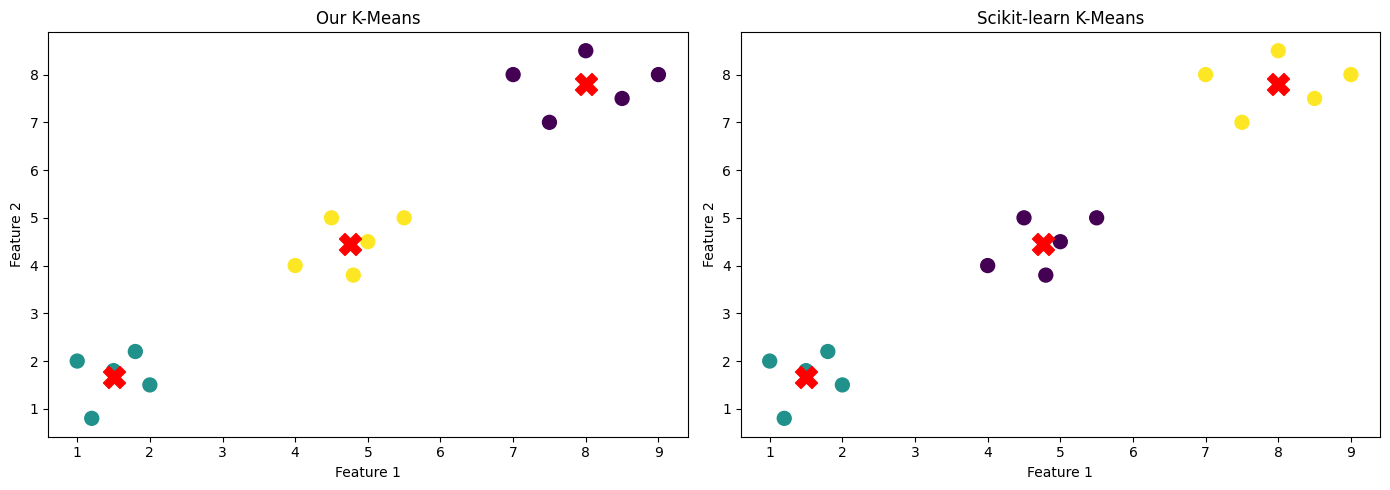

In [70]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5)
)

# Our implementation
axes[0].scatter(
    X[:, 0],
    X[:, 1],
    c=our_labels,
    cmap="viridis",
    s=100
)

axes[0].scatter(
    our_model.centroids[:, 0],
    our_model.centroids[:, 1],
    color="red",
    marker="X",
    s=250
)

axes[0].set_title("Our K-Means")

# Scikit-learn
axes[1].scatter(
    X[:, 0],
    X[:, 1],
    c=sklearn_labels,
    cmap="viridis",
    s=100
)

axes[1].scatter(
    sklearn_model.cluster_centers_[:, 0],
    sklearn_model.cluster_centers_[:, 1],
    color="red",
    marker="X",
    s=250
)

axes[1].set_title("Scikit-learn K-Means")

for ax in axes:
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")

plt.tight_layout()
plt.show()


## 14. Effect of Random Initialization

K-Means can produce different results depending on the initial centroid positions.

Let's train the same model using several random seeds.


In [71]:
for seed in range(10):

    model_seed = KMeans(
        k=3,
        random_state=seed
    )

    model_seed.fit(X)

    print(
        f"Seed {seed:2d} | "
        f"Inertia: {model_seed.inertia_:8.2f} | "
        f"Iterations: {model_seed.n_iter_:2d}"
    )


Seed  0 | Inertia:    47.94 | Iterations:  3
Seed  1 | Inertia:    52.82 | Iterations:  2
Seed  2 | Inertia:    61.94 | Iterations:  2
Seed  3 | Inertia:    61.25 | Iterations:  2
Seed  4 | Inertia:     8.16 | Iterations:  3
Seed  5 | Inertia:     8.16 | Iterations:  2
Seed  6 | Inertia:    52.44 | Iterations:  2
Seed  7 | Inertia:     8.16 | Iterations:  3
Seed  8 | Inertia:     8.16 | Iterations:  3
Seed  9 | Inertia:     8.16 | Iterations:  3


# 15. Final Summary

## What we implemented

We implemented K-Means clustering from scratch using NumPy.

The implementation includes:

- Random centroid initialization
- Euclidean distance calculation
- Cluster assignment
- Centroid updates
- Empty-cluster handling
- Convergence detection
- Prediction
- Inertia calculation
- Centroid movement tracking

## What we learned

### K-Means optimization

K-Means alternates between:

1. Assign each point to the nearest centroid.
2. Recalculate each centroid using the mean of its assigned points.

### Inertia

Measures the total squared distance between points and their assigned centroids.

### Elbow Method

Helps identify a reasonable K by looking for diminishing returns in inertia.

### Silhouette Score

Measures how well-separated the clusters are.

### Feature Scaling

Important because K-Means relies on distance calculations.

### Initialization

Different initial centroids can lead to different solutions.

K-Means++ is a common improvement over purely random initialization.

## Limitations

This implementation is intentionally educational.

It does not include:

- K-Means++ initialization
- Multiple random initializations
- Mini-batch training
- Advanced numerical optimizations
- Automatic selection of K

These are possible improvements for a production implementation.

## Key takeaway

K-Means is conceptually simple:

    Assign → Update → Repeat

But practical clustering requires additional decisions around:

- Choosing K
- Feature scaling
- Initialization
- Evaluation
- Interpreting clusters
